In [ ]:
import segmentation_models_pytorch as smp
import torch
import pickle
import albumentations as A
from utils.Loader.myLoader import SegDataset
from torch.utils.data import DataLoader
import seaborn as sns
import random
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import glob
import math
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc, roc_curve, roc_auc_score, matthews_corrcoef, average_precision_score, recall_score
from sklearn.utils import resample
from sklearn.calibration import calibration_curve
matplotlib.rcParams['pdf.fonttype'] = 42

/home/bio-21/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/work/run/projects/bio-21/Anaconda3/envs/2D-seg/lib/python3.10/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
os.makedirs("output-classification", exist_ok = True)

os.makedirs("output-classification/1-data_stats", exist_ok=True)
os.makedirs("output-classification/2-images", exist_ok = True)
os.makedirs("output-classification/3-Model_performance", exist_ok=True)
os.makedirs("output-classification/4-test_performance", exist_ok=True)
os.makedirs("output-classification/5-false_prediction_demo", exist_ok=True)

# Try to use the same split here

In [3]:
with open('output/test_files.pkl', 'rb') as test_file:
    test_files = pickle.load(test_file)

with open('output/train_files.pkl', 'rb') as train_file:
    train_files = pickle.load(train_file)

with open('output/val_files.pkl', 'rb') as val_file:
    val_files = pickle.load(val_file)

In [4]:
test_files

[{'image': 'Dataset/CXR/030_disease.jpg',
  'label': 'Dataset/Mask/030_disease_mask.jpg'},
 {'image': 'Dataset/CXR/077_disease.jpg',
  'label': 'Dataset/Mask/077_disease_mask.jpg'},
 {'image': 'Dataset/CXR/009_hc.jpg', 'label': 'Dataset/Mask/009_hc_mask.jpg'},
 {'image': 'Dataset/CXR/025_hc.jpg', 'label': 'Dataset/Mask/025_hc_mask.jpg'},
 {'image': 'Dataset/CXR/047_disease.jpg',
  'label': 'Dataset/Mask/047_disease_mask.jpg'},
 {'image': 'Dataset/CXR/038_hc.jpg', 'label': 'Dataset/Mask/038_hc_mask.jpg'},
 {'image': 'Dataset/CXR/071_hc.jpg', 'label': 'Dataset/Mask/071_hc_mask.jpg'},
 {'image': 'Dataset/CXR/011_disease.jpg',
  'label': 'Dataset/Mask/011_disease_mask.jpg'},
 {'image': 'Dataset/CXR/049_disease.jpg',
  'label': 'Dataset/Mask/049_disease_mask.jpg'},
 {'image': 'Dataset/CXR/016_hc.jpg', 'label': 'Dataset/Mask/016_hc_mask.jpg'},
 {'image': 'Dataset/CXR/069_hc.jpg', 'label': 'Dataset/Mask/069_hc_mask.jpg'},
 {'image': 'Dataset/CXR/059_hc.jpg', 'label': 'Dataset/Mask/059_hc_mask

In [11]:
from collections import Counter
labels_stats = [x["image"].split("_")[-1].split(".")[0] for x in train_files ]

counts = Counter(labels_stats)
print(counts)

Counter({'disease': 73, 'hc': 67})


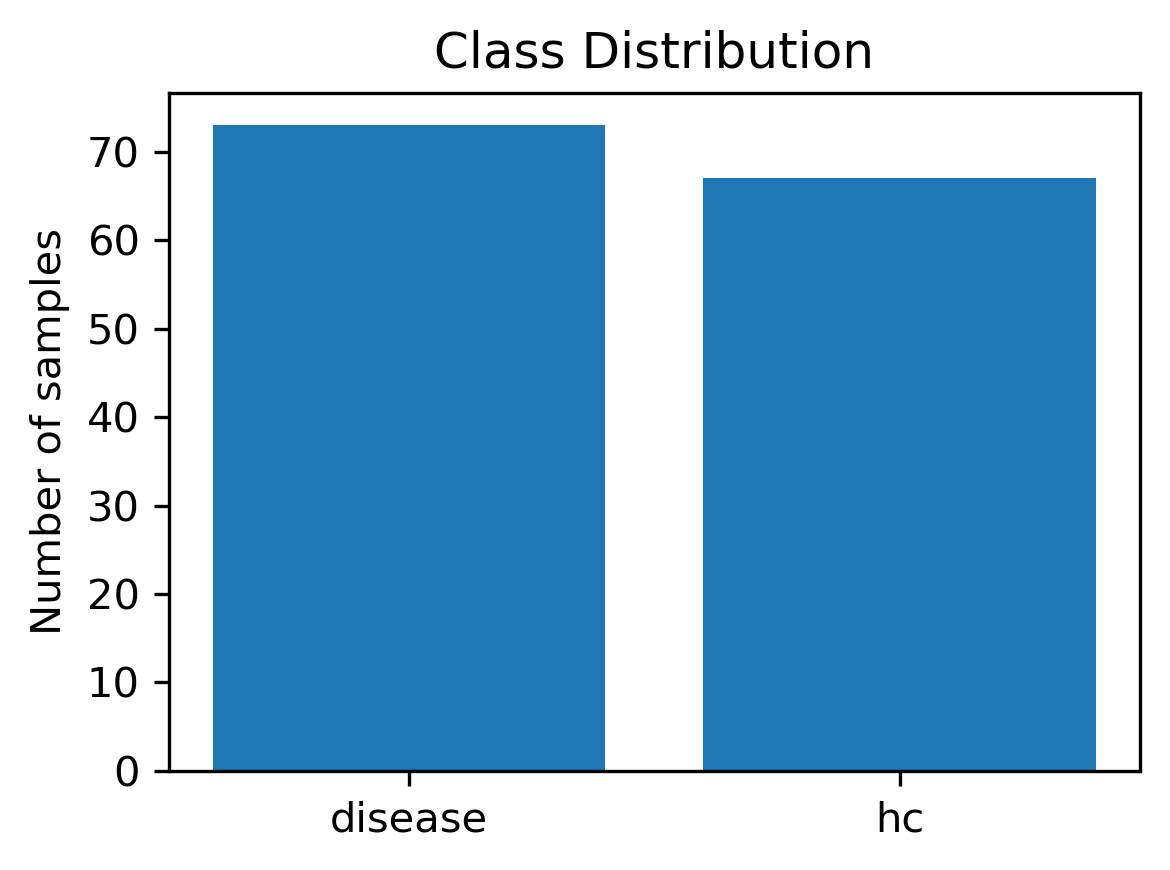

In [12]:
plt.figure(figsize=(4, 3), dpi=300)
plt.bar(counts.keys(), counts.values())
plt.ylabel("Number of samples")
plt.title("Class Distribution")
plt.tight_layout()
plt.savefig("output-classification/1-data_stats/class-distribution.pdf", format = "pdf", dpi=300, bbox_inches = "tight")
plt.show()

# Load the selected model

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device # check device

device(type='cuda')

In [ ]:
model_select = 148
Unet_model = smp.from_pretrained(f'my_model/{model_select}').to(device)

Loading weights from local directory


## Create a new model for classifier training

In [20]:
# we can change the label mapping here, and the aux param should change accordingly
label_map = {
    "hc": 0,
    "disease": 1
}

aux_params=dict(    
    activation=None,      # activation function, default is None
    dropout=0.5,
    classes=1,            # define number of output labels, for 2 classes we set to 1, for more than 2 class then we should use one-hot coding for labels 
)
model_select = 148 # !!! Remember to change this for your model
clean_unet_model = smp.from_pretrained(f'my_model/{model_select}', aux_params = aux_params, strict=False).to(device)

Loading weights from local directory


In [8]:
TARGET_SIZE = (224, 224) # Example input height, width
# https://explore.albumentations.ai/ see the augmentations' effects
train_transform = A.Compose([
    # Resize shortest side of image and mask to TARGET_SIZE * 2, maintaining aspect ratio
    A.SmallestMaxSize(max_size=TARGET_SIZE[0], p=1.0),
    # Take a random crop
    A.RandomCrop(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    A.CropNonEmptyMaskIfExists(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    # Apply one of 8 random symmetries (flips/rotations)
    A.SquareSymmetry(p=0.3), # Replaces Horizontal/Vertical Flips
    # Optional: Further rotation if SquareSymmetry isn't sufficient or desired
    A.Rotate(limit=30, p=0.3),
    # Optional: Image-only transforms (applied only to image)
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(std_range=(0.1, 0.2), p=0.2),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
    # --- Framework-specific steps ---
    # Normalize image (mask is not normalized)
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    # Convert image and mask to PyTorch tensors
    A.ToTensorV2()
], seed=42)

val_transform = A.Compose([
    # Resize shortest side of image and mask to TARGET_SIZE * 2, maintaining aspect ratio
    A.SmallestMaxSize(max_size=TARGET_SIZE[0], p=1.0),
    A.RandomCrop(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    A.CropNonEmptyMaskIfExists(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    # Convert image and mask to PyTorch tensors
    A.ToTensorV2()
], seed=42)

test_transform = A.Compose([
    # Resize shortest side of image and mask to TARGET_SIZE * 2, maintaining aspect ratio
    A.SmallestMaxSize(max_size=TARGET_SIZE[0], p=1.0),
    A.RandomCrop(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    A.CropNonEmptyMaskIfExists(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    # Convert image and mask to PyTorch tensors
    A.ToTensorV2()
], seed=42)

# batch_size = 16

In [17]:
train_dataset = SegDataset(train_files, transform=train_transform)
val_dataset   = SegDataset(val_files, transform=val_transform)
test_dataset   = SegDataset(test_files, transform=val_transform)

In [18]:
sample = random.choice(test_files) # pick one sample randomly
sample

{'image': 'Dataset/CXR/046_hc.jpg', 'label': 'Dataset/Mask/046_hc_mask.jpg'}

In [19]:
test_dataset = SegDataset([sample], transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

## Check weights loading correctly

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


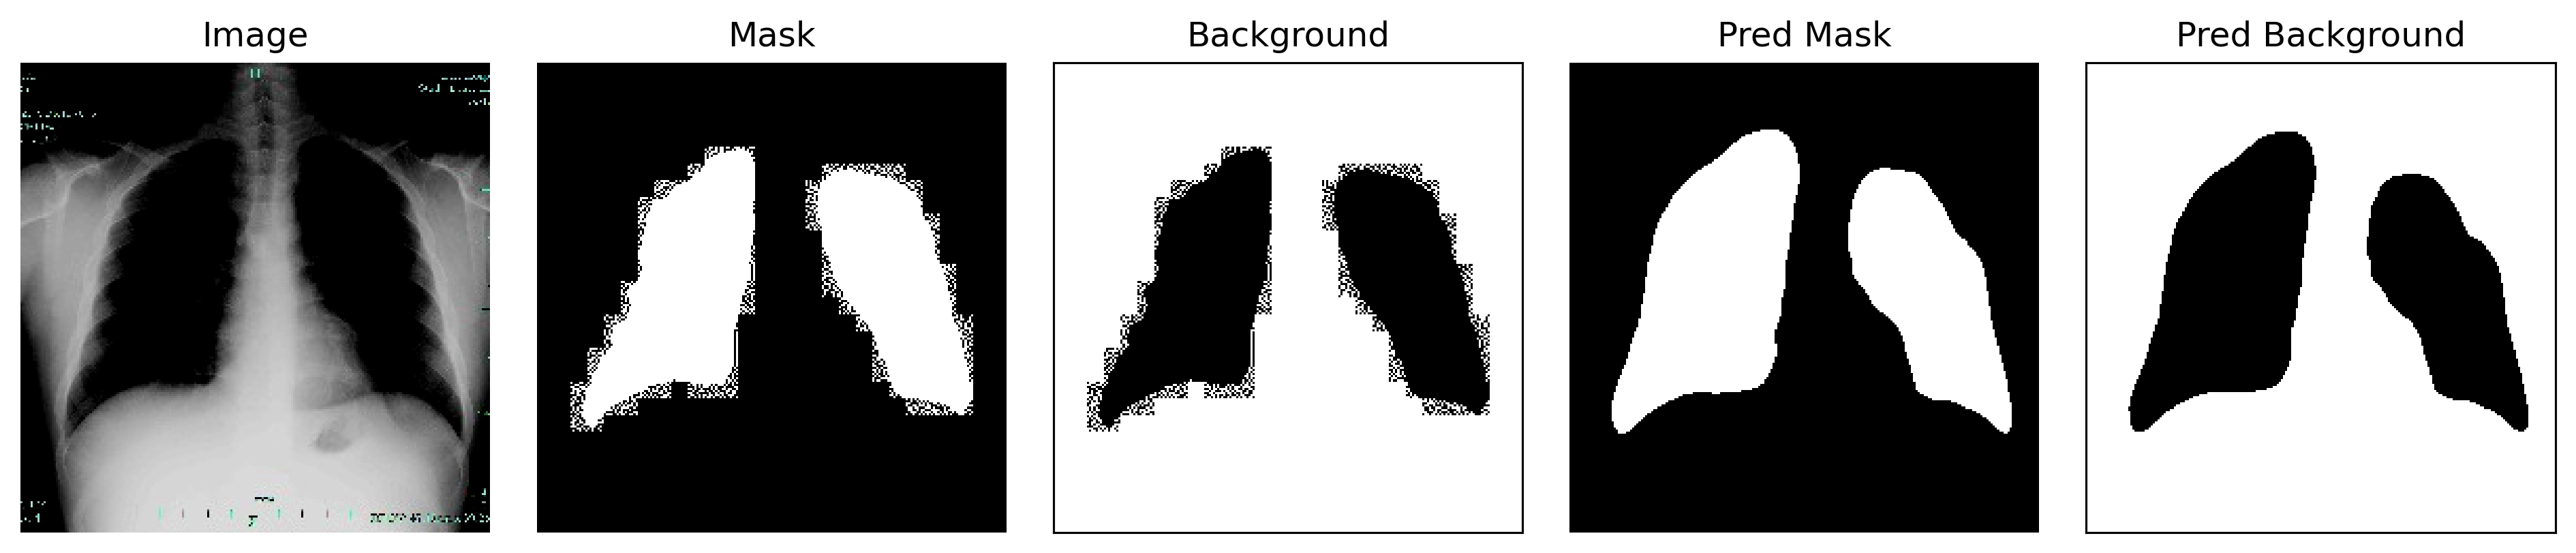

In [43]:
clean_unet_model.eval()
for image, mask, sample in test_loader:
    # targets = [SemanticSegmentationTarget(0, mask[0,0].numpy())]
    # print(targets)
    outputs = Unet_model(image.to("cuda"))
    pred = (torch.sigmoid(outputs) > 0.5 ).float()

    fig = plt.figure(figsize=(16, 4),dpi=300)
    gs = gridspec.GridSpec(1, 5, height_ratios=[1], hspace=0.05, wspace=0.1)

    # Top row: images
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])
    ax2 = fig.add_subplot(gs[2])
    ax3 = fig.add_subplot(gs[3])
    ax4 = fig.add_subplot(gs[4])
    # ax5 = fig.add_subplot(gs[0,5])

    # Plot images
    ax0.imshow(image.squeeze(0).permute(1, 2, 0).numpy(), cmap="gray", interpolation="none")
    ax0.set_title("Image")
    ax0.axis("off")

    ax1.imshow(mask.squeeze(0).numpy()[0], cmap="gray", interpolation="none")
    ax1.set_title("Mask")
    ax1.axis("off")

    ax2.imshow(mask.squeeze(0).numpy()[1], cmap="gray", interpolation="none")
    ax2.set_title("Background")
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.spines["left"].set_linewidth(0.75)
    ax2.spines["right"].set_linewidth(0.75)
    ax2.spines["top"].set_linewidth(0.75)
    ax2.spines["bottom"].set_linewidth(0.75)

    ax3.imshow(pred.squeeze(0).cpu().numpy()[0], cmap="gray", interpolation="none")
    ax3.set_title("Pred Mask")
    ax3.axis("off")

    ax4.imshow(pred.squeeze(0).cpu().numpy()[1], cmap="gray", interpolation="none")
    ax4.set_title("Pred Background")
    ax4.set_xticks([])
    ax4.set_yticks([])
    ax4.spines["left"].set_linewidth(0.75)
    ax4.spines["right"].set_linewidth(0.75)
    ax4.spines["top"].set_linewidth(0.75)
    ax4.spines["bottom"].set_linewidth(0.75)
    # ax5.axis("off")
    # plt.tight_layout()
    # plt.savefig(f"output/5-Model_explanation/Model{model_select}_explanation.pdf", format="pdf")
    plt.show()

## For testing only

In [5]:
data_dir = r"Dataset"
train_images = sorted(glob.glob(os.path.join(data_dir, "CXR", "*.jpg"), recursive=True))
train_labels = sorted(glob.glob(os.path.join(data_dir, "Mask", "*.jpg"), recursive=True))

print(len(train_labels)) # check number of samples

data_dicts = [{"image": image_name, "label": label_name} for image_name, label_name in zip(train_images, train_labels)]

print(len(data_dicts))


200
200


In [6]:
random.seed(42)
random.shuffle(data_dicts)
# calculate splits
train_portion = math.ceil(len(data_dicts) * 0.7)
test_portion = math.floor(len(data_dicts) * 0.15)
valid_portion = len(data_dicts) - test_portion - train_portion

print(train_portion)
print(test_portion)
print(valid_portion)
print((train_portion + test_portion + valid_portion) == len(data_dicts))

train_files, test_files, val_files = data_dicts[0:train_portion], data_dicts[train_portion:(train_portion+test_portion)], data_dicts[(train_portion+test_portion):(train_portion + test_portion + valid_portion)]

140
30
30
True


In [9]:
train_dataset = SegDataset(train_files, transform=val_transform)
val_dataset   = SegDataset(val_files, transform=val_transform)
test_dataset   = SegDataset(test_files, transform=val_transform)

In [48]:
# freeze the weights in the encoder and segmentation head by disabling the gradient
for param in clean_unet_model.parameters():
    param.requires_grad = False
for param in clean_unet_model.classification_head.parameters():
    param.requires_grad = True

In [10]:
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = optim.Adam(clean_unet_model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)


NameError: name 'clean_unet_model' is not defined

In [ ]:
# pre-defined best metrics, for model selection and saving
best_f1         = 0.6
best_recall     = 0.5
best_acc        = 0.7
best_train_loss = 0.3
best_val_loss   = 0.3
# best_IOU        = 0.5

# simple hyperparameters, normally this set up can have a result of around 0.7 IoU, depends on the number of masks
epochs          = 200 # train for 200 epochs
batch_size      = 16  # adjust batch to optimize the use of GPU, 224 * 224 @ batch size 16 takes up around 3GB of GPU Memory

In [51]:
# lists to store metrics
train_losses = []
eval_losses = []
f1_scores = []
precision_scores = []
recall_scores = []
accuracy_scores = []
num_epoch = []

In [52]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [54]:
pbar = tqdm(range(epochs))
len_loader = len(train_loader)
len_eval_loader = len(val_loader)

for epoch in pbar:
    epoch_loss = 0
    num_epoch.append(epoch)
    clean_unet_model.train() # enable training mode

    for image, masks, types in train_loader:
        pbar.set_description("Training ...")
        
        # print(f"{image.shape} {masks.shape}")
        # img_np = image.squeeze(0).permute(1, 2, 0).numpy() # make sure (H, W, C)
        # print(f"{img_np.shape}")
        # mask_np = masks.squeeze(0).permute(1, 2, 0).numpy()
        # fig, axes = plt.subplots(1, 3, figsize=(8, 4))

        # axes[0].imshow(img_np)
        # axes[0].set_title("Image")
        # axes[0].axis("off")

        # axes[1].imshow(mask_np, cmap="gray")
        # axes[1].set_title("Mask")
        # axes[1].axis("off")

        # axes[2].imshow(img_np)
        # axes[2].imshow(mask_np, cmap="Reds", alpha=0.4) # ListedColormap(["#FFFFFF"])
        # axes[2].set_title("Overlay")
        # axes[2].axis("off")

        # plt.tight_layout()
        # plt.show()

        image = image.to(device)
        # masks = masks.to(device)
        labels =  torch.tensor([
                    label_map[p.split('_')[-1].split('.')[0]]
                    for p in types['image']
                ], dtype=torch.float32).to(device) # mapping the class on the fly
        # print(f"{image.shape} {masks.shape}")
        optimizer.zero_grad()

        seg_logits, cls_logits  = clean_unet_model(image)
        # print(cls_logits)
        loss = criterion(cls_logits, labels.unsqueeze(1)) # compute dice loss

        loss.backward() # back propagation
        optimizer.step() # optimize weights

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len_loader

    train_losses.append(avg_train_loss)

    # evaluation loop
    clean_unet_model.eval() # enable model evaluation mode
    
    
    val_loss = 0
    # stop gradient calculation
    with torch.no_grad():
        all_tp, all_fp, all_fn, all_tn = [], [], [], []
        for image, masks, types in val_loader:
            pbar.set_description("Validating ...")
            # print(masks)
            image = image.to(device)
            # masks = masks.to(device)
            labels = torch.tensor([
                    label_map[p.split('_')[-1].split('.')[0]]
                    for p in types['image']
                ], dtype=torch.float32).to(device)

            seg_logits, cls_logits = clean_unet_model(image)
            loss = criterion(cls_logits, labels.unsqueeze(1))

            val_loss += loss.item()
            outputs = torch.sigmoid(cls_logits)
            # print(f"{outputs[:, 0:1].shape}")
            tp, fp, fn, tn = smp.metrics.get_stats(
                cls_logits, labels.unsqueeze(1).long(), mode='binary', threshold=0.5
            )

            all_tp.append(tp)
            all_fp.append(fp)
            all_fn.append(fn)
            all_tn.append(tn)

        avg_val_loss = val_loss / len_eval_loader
        eval_losses.append(avg_val_loss)

        scheduler.step(avg_val_loss)
        
        # Concatenate statistics
        tp = torch.cat(all_tp, dim=0)
        fp = torch.cat(all_fp, dim=0)
        fn = torch.cat(all_fn, dim=0)
        tn = torch.cat(all_tn, dim=0)

        # Compute metrics
        f1 = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro")
        precision = smp.metrics.precision(tp, fp, fn, tn, reduction="macro")
        recall = smp.metrics.recall(tp, fp, fn, tn, reduction="micro-imagewise")
        accuracy = smp.metrics.accuracy(tp, fp, fn, tn, reduction="macro")

        current_lr = optimizer.param_groups[0]['lr']

        pbar.set_postfix({"Validation recall": recall.item(), "BCEWithLogitsLoss": avg_val_loss, "current learning rate": current_lr})

        f1_scores.append(float(f1.cpu().numpy()))
        precision_scores.append(float(precision.cpu().numpy()))
        recall_scores.append(float(recall.cpu().numpy()))
        accuracy_scores.append(float(accuracy.cpu().numpy()))

        if recall.item() > best_recall or (avg_train_loss < best_train_loss and 
                                     avg_val_loss < best_val_loss and 
                                     f1.item() > best_f1 and 
                                     accuracy.item() > best_acc):
                best_f1         = f1.item()
                best_recall     = recall.item()
                best_acc        = accuracy.item()
                best_train_loss = avg_train_loss
                best_val_loss   = avg_val_loss
                # best_recall     = recall.item()
                clean_unet_model.save_pretrained(f'./my_classification_model/{epoch}', metrics={"epoch":epoch, 
                                                                      "Recall": recall.item(), 
                                                                      "accuracy": accuracy.item(), 
                                                                      "F1": f1.item(), 
                                                                      "Precision":precision.item(), 
                                                                      "Recall":recall.item(),
                                                                      "Dice":avg_val_loss})



metrics_df = pd.DataFrame({
    "Epoch": num_epoch,
    "F1": f1_scores,
    "Precision": precision_scores,
    "Recall": recall_scores,
    "Accuracy" : accuracy_scores,
    "Training_loss" : train_losses,
    "Validation_loss": eval_losses,
})

metrics_df.to_csv("output-classification/3-Model_performance/classification_model_metrics.csv", index=False)

  0%|          | 0/200 [00:00<?, ?it/s]

Validating ...: 100%|██████████| 200/200 [03:46<00:00,  1.13s/it, Validation recall=0.533, BCEWithLogitsLoss=0.693, current learning rate=1e-8] 


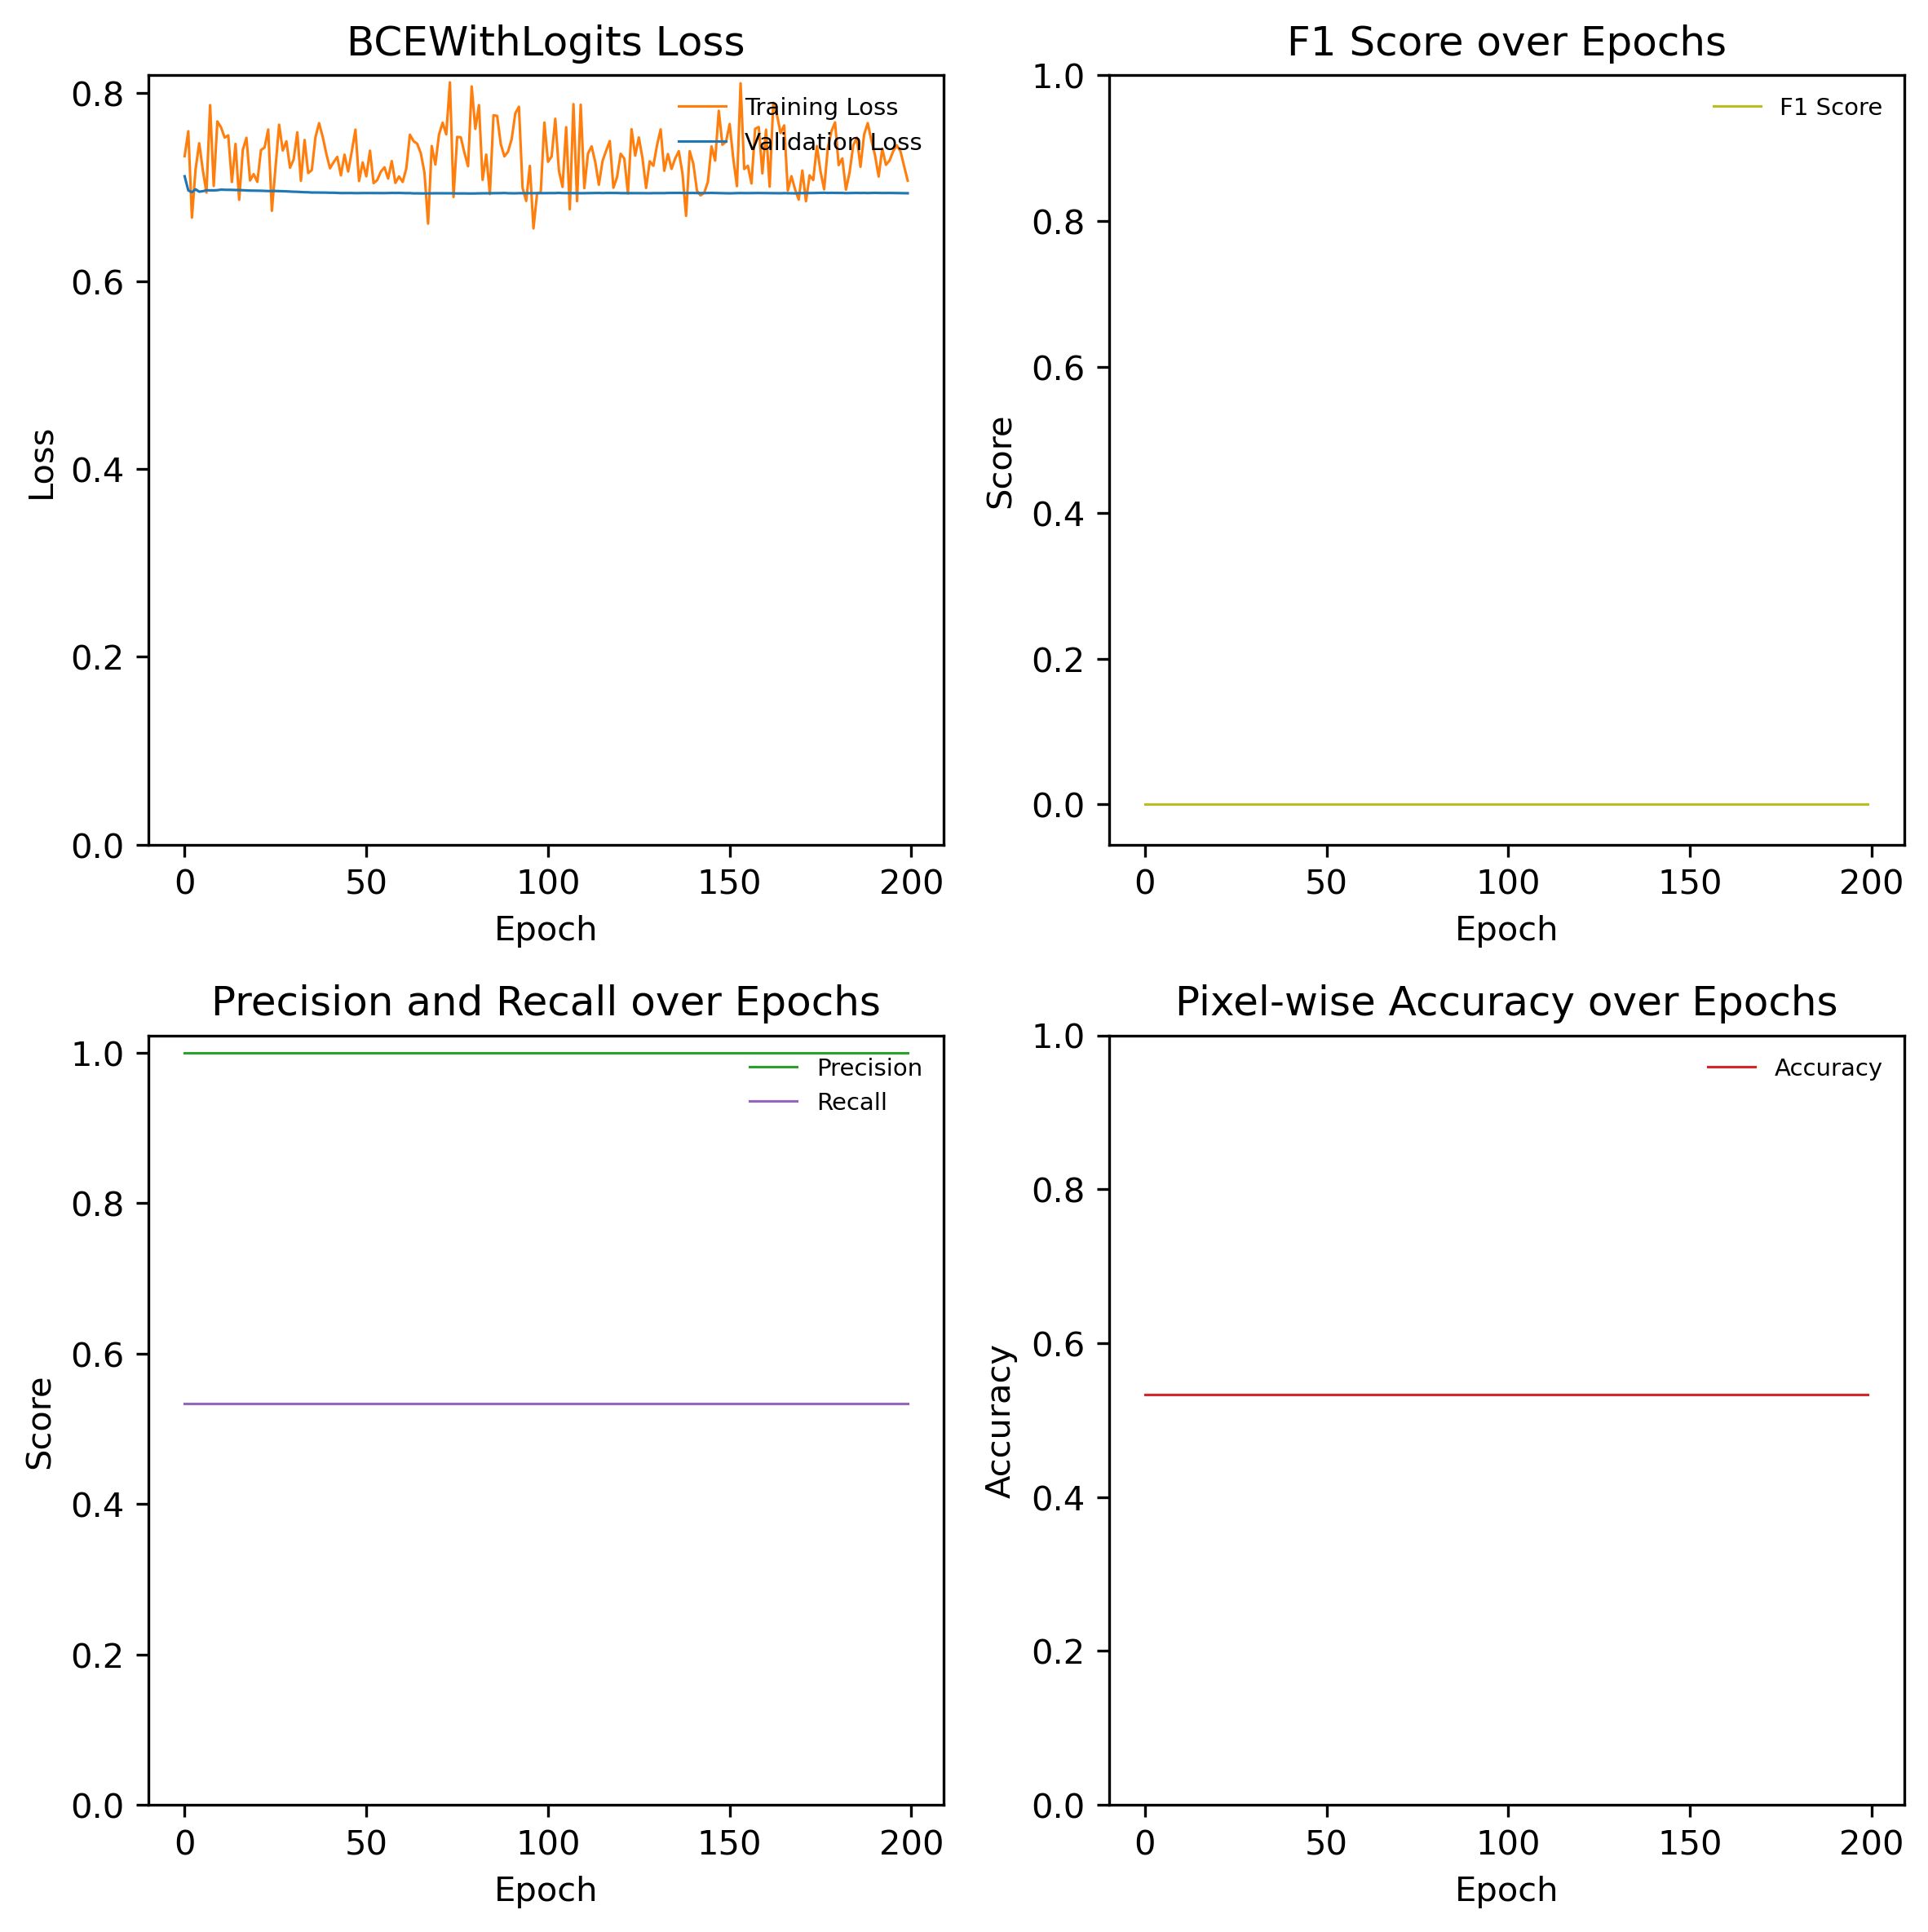

In [55]:
max_tick = max(metrics_df["Training_loss"].max(), metrics_df["Validation_loss"].max())

plt.figure(figsize=(8,8), dpi=300)
plt.subplot(221)
sns.lineplot(data=metrics_df, x="Epoch", y="Training_loss", label="Training Loss", linewidth = 0.75, color="tab:orange")
sns.lineplot(data=metrics_df, x="Epoch", y="Validation_loss", label="Validation Loss", linewidth = 0.75, color="tab:blue")
# plt.xticks(range(0,max_tick+50,50))
plt.yticks(np.arange(0, max_tick+0.1, 0.2))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BCEWithLogits Loss")
plt.legend(fontsize=7, loc="upper right", frameon=False)

plt.subplot(222)
# max_tick = max(metrics_df["IoU"].max(), metrics_df["F1"].max())
# sns.lineplot(data=metrics_df, x="Epoch", y="IoU", label="IoU", color="tab:cyan",linewidth = 0.75)
sns.lineplot(data=metrics_df, x="Epoch", y="F1", label="F1 Score", color="tab:olive", linewidth = 0.75)
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.yticks(np.arange(0, 1+0.2, 0.2))
plt.title("F1 Score over Epochs")
plt.legend(fontsize=7, loc="upper right", frameon=False)

plt.subplot(223)
sns.lineplot(data=metrics_df, x="Epoch", y="Precision", label="Precision",color="tab:green",linewidth = 0.75)
sns.lineplot(data=metrics_df, x="Epoch", y="Recall", label="Recall",color="tab:purple",linewidth = 0.75)
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.yticks(np.arange(0, 1+0.2, 0.2))
plt.title("Precision and Recall over Epochs")
plt.legend(fontsize=7, loc="upper right", frameon=False)

plt.subplot(224)
sns.lineplot(data=metrics_df, x="Epoch", y="Accuracy",label="Accuracy", color="tab:red",linewidth=0.75)
plt.title("Pixel-wise Accuracy over Epochs")
plt.yticks(np.arange(0, 1+0.2, 0.2))
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(fontsize=7, loc="upper right", frameon=False)

plt.tight_layout()
plt.savefig("output-classification/3-Model_performance/classificaiton_model_performance.pdf", format = "pdf")
plt.show()

## Model selection

In [12]:
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False) # set to 1 for easy plotting
len_test_loader = len(test_loader)
len_test_loader

30

In [11]:
all_models = sorted(glob.glob(os.path.join("my_classification_model", "*"), recursive=True))
all_models

['my_classification_model/0']

In [ ]:
test_f1_scores = []
test_precision_scores = []
test_recall_scores = []
test_accuracy_scores = []
test_losses = []

pred_label_probs = []
true_label = []
pred_label = []
sample_name = []
all_models = sorted(glob.glob(os.path.join("my_classification_model", "*"), recursive=True))

for trained_model in all_models:
    # model_select = 0
    model = smp.from_pretrained(f'{trained_model}').to(device)
    model.eval() # enable model evaluation mode
    test_loss = 0
    pbar = tqdm(test_loader)
    # stop gradient calculation
    with torch.no_grad():
        all_tp, all_fp, all_fn, all_tn = [], [], [], []
        for image, masks, types in pbar:
            # print(types)
            pbar.set_description("Testing ...")
            # print(masks.shape)
            sample_name.extend(types["image"])
            img_np = image.squeeze(0).permute(1, 2, 0).numpy() # make sure (H, W, C)
            mask_np = masks.squeeze(0).numpy()
            # print(mask_np.shape)
            image = image.to(device)
            masks = masks.to(device)
            
            labels = torch.tensor([
                        label_map[p.split('_')[-1].split('.')[0]]
                        for p in types['image']
                    ], dtype=torch.float32).to(device)
            
            seg_logits, cls_logits = model(image)
            loss = criterion(cls_logits, labels.unsqueeze(1))

            test_loss += loss.item()
            
            # print(f"{outputs[:, 0:1].shape}")
            
            outputs = torch.sigmoid(cls_logits)
            pred_mask = (seg_logits.cpu() > 0.5).squeeze(0).numpy()

            # outputs_flat = outputs.squeeze().detach()
            # print(outputs_flat)
            pred_label_probs.extend([x.item() for x in outputs.cpu()])
            pred_label.extend([int((x.item() > 0.5)) for x in outputs.cpu()])
            true_label.extend([x.item() for x in labels.cpu()])

            tp, fp, fn, tn = smp.metrics.get_stats(
                cls_logits, labels.unsqueeze(1).long(), mode='binary', threshold=0.5
            )

            all_tp.append(tp)
            all_fp.append(fp)
            all_fn.append(fn)
            all_tn.append(tn)

        avg_test_loss = test_loss / len_test_loader
        
        # Concatenate statistics
        tp = torch.cat(all_tp, dim=0)
        fp = torch.cat(all_fp, dim=0)
        fn = torch.cat(all_fn, dim=0)
        tn = torch.cat(all_tn, dim=0)

        # Compute metrics
        f1 = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro")
        precision = smp.metrics.precision(tp, fp, fn, tn, reduction="macro")
        recall = smp.metrics.recall(tp, fp, fn, tn, reduction="micro-imagewise")
        accuracy = smp.metrics.accuracy(tp, fp, fn, tn, reduction="macro")

        test_f1_scores.append(float(f1.cpu().numpy()))
        test_precision_scores.append(float(precision.cpu().numpy()))
        test_recall_scores.append(float(recall.cpu().numpy()))
        test_accuracy_scores.append(float(accuracy.cpu().numpy()))
        test_losses.append(avg_test_loss)

        labels_df = pd.DataFrame({
            "Sample": sample_name,
            "pred_labels":pred_label,
            "pred_label_probs":pred_label_probs,
            "true_labels":true_label
        })
        labels_df.to_csv(f"output-classification/4-test_performance/classification_test_pred_df-Model_{trained_model.split('/')[-1]}.csv", index=False)

test_metrics_df = pd.DataFrame({
    "Model":[int(x.split('/')[-1]) for x in all_models],
    "Model_str": [x.split('/')[-1] for x in all_models],
    "F1": test_f1_scores,
    "Precision": test_precision_scores,
    "Recall": test_recall_scores,
    "Accuracy" : test_accuracy_scores,
    "Test_loss" : test_losses
})

# labels_df = pd.DataFrame({
#     "Sample": sample_name,
#     "pred_labels":pred_label,
#     "pred_label_probs":pred_label_probs,
#     "true_labels":true_label
# })

# os.makedirs("Model_performance", exist_ok=True)
test_metrics_df.sort_values(by="Model").to_csv("output-classification/4-test_performace/classification_test_metrics_df.csv", index=False)


Loading weights from local directory


Testing ...: 100%|██████████| 30/30 [00:01<00:00, 15.95it/s]


Loading weights from local directory


Testing ...: 100%|██████████| 30/30 [00:00<00:00, 70.09it/s]


Loading weights from local directory


Testing ...: 100%|██████████| 30/30 [00:00<00:00, 65.33it/s]


In [22]:
# test_metrics_df
idx = test_metrics_df["Recall"].idxmax()
print(f"Model {test_metrics_df.loc[idx]['Model']} has the highest Recall. Recall:{test_metrics_df.loc[idx]['Recall']: .2f} Precision:{test_metrics_df.loc[idx]['Precision']: .2f} F1:{test_metrics_df.loc[idx]['F1']: .2f} Loss:{test_metrics_df.loc[idx]['Test_loss']: .3f}")
idx = test_metrics_df["Precision"].idxmin()
print(f"Model {test_metrics_df.loc[idx]['Model']} has the highest Precision. Recall:{test_metrics_df.loc[idx]['Recall']: .2f} Precision:{test_metrics_df.loc[idx]['Precision']: .2f} F1:{test_metrics_df.loc[idx]['F1']: .2f} Loss:{test_metrics_df.loc[idx]['Test_loss']: .3f}")
idx = test_metrics_df["Test_loss"].idxmin()
print(f"Model {test_metrics_df.loc[idx]['Model']} has the lowest loss. Recall:{test_metrics_df.loc[idx]['Recall']: .2f} Precision:{test_metrics_df.loc[idx]['Precision']: .2f} F1:{test_metrics_df.loc[idx]['F1']: .2f} Loss:{test_metrics_df.loc[idx]['Test_loss']: .3f}")
idx = test_metrics_df["F1"].idxmax()
print(f"Model {test_metrics_df.loc[idx]['Model']} has the highest F1. Recall:{test_metrics_df.loc[idx]['Recall']: .2f} Precision:{test_metrics_df.loc[idx]['Precision']: .2f} F1:{test_metrics_df.loc[idx]['F1']: .2f} Loss:{test_metrics_df.loc[idx]['Test_loss']: .3f}")

Model 0 has the highest Recall. Recall: 0.57 Precision: 1.00 F1: 0.00 Loss: 0.720
Model 0 has the highest Precision. Recall: 0.57 Precision: 1.00 F1: 0.00 Loss: 0.720
Model 0 has the lowest loss. Recall: 0.57 Precision: 1.00 F1: 0.00 Loss: 0.720
Model 0 has the highest F1. Recall: 0.57 Precision: 1.00 F1: 0.00 Loss: 0.720


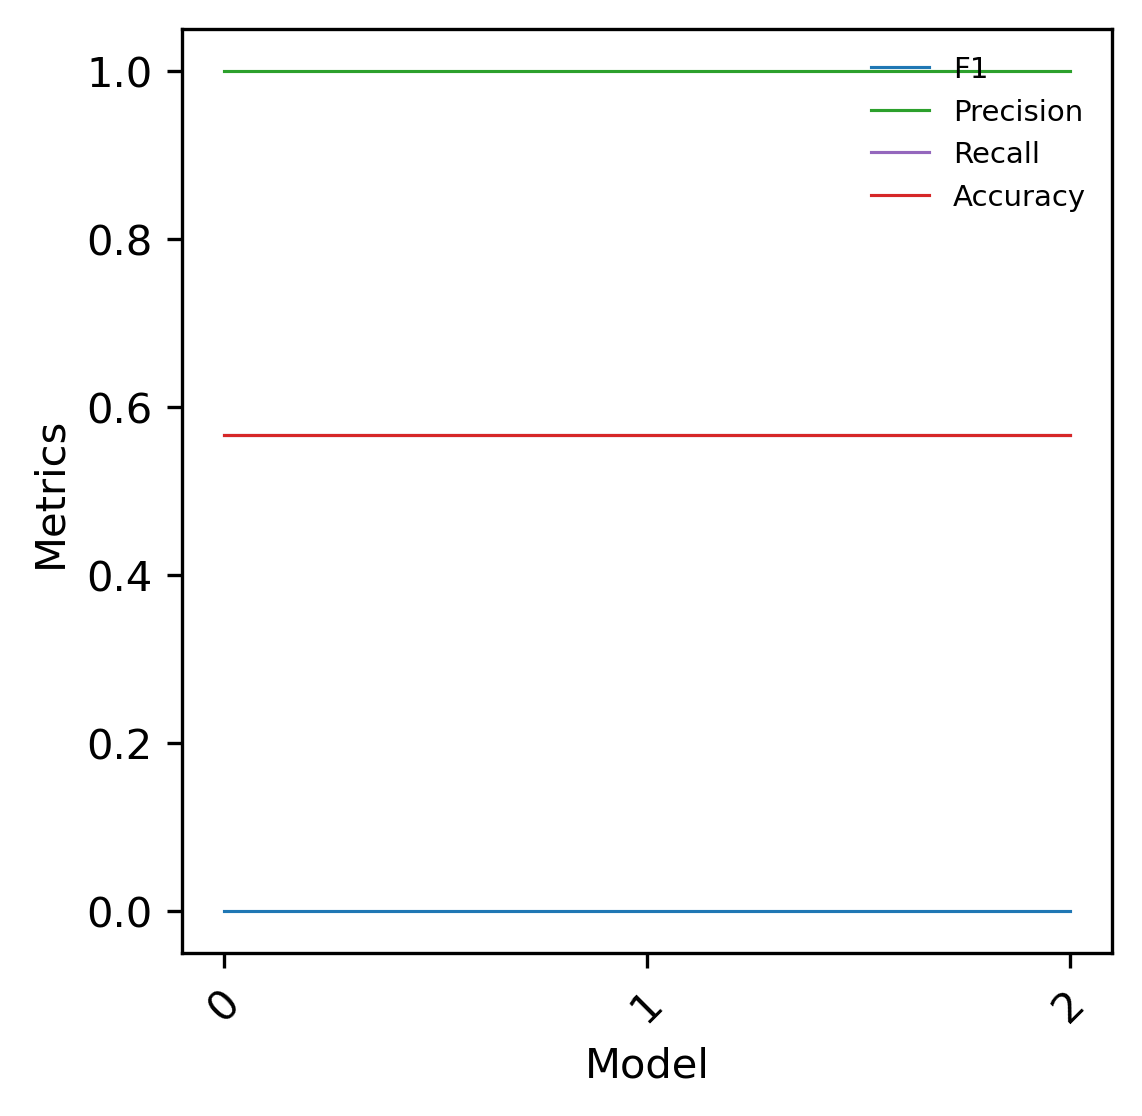

In [24]:
# test_metrics_df
plt.figure(figsize=(4,4), dpi=300)
# plt.subplot(121)
# sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "IoU", linewidth = 0.75, label="IoU", color="tab:orange" )
sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "F1", linewidth = 0.75, label="F1",color="tab:blue" )
sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Precision", linewidth = 0.75, label="Precision",color="tab:green" )
sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Recall", linewidth = 0.75, label="Recall",color="tab:purple" )
sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Accuracy", linewidth = 0.75, label="Accuracy",color="tab:red" )
plt.xticks(rotation = 45)
plt.xlabel("Model")
plt.ylabel("Metrics")
# plt.yscale('log')
plt.legend(fontsize=7,loc="upper right", frameon=False)

# plt.subplot(122)
# sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Test_loss", linewidth = 0.75, label="Test_loss",color="tab:brown" )
# sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Test_Jaccard_Loss", linewidth = 0.75, label="Jaccard_Loss",color="tab:pink" )
# sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Test_Tversky_Loss", linewidth = 0.75, label="Tversky_Loss",color="olive" )
# sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Test_Focal_Loss", linewidth = 0.75, label="Focal_Loss",color="tab:cyan" )
# sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Test_Lovasz_Loss", linewidth = 0.75, label="Lovasz_Loss",color="orangered" )
# plt.xticks(rotation = 45)
# plt.xlabel("Model")
# plt.ylabel("Losses")
# # plt.yscale('log')
# plt.legend(fontsize=7,loc="upper right", frameon=False)

plt.savefig("output-classification/4-test_performance/test_metrics_vs_models.pdf", format = "pdf",dpi = 300,bbox_inches="tight")

In [37]:
print(pred_label_probs)
print(true_label) 
print(pred_label) 

[0.5650744438171387, 0.5616477727890015, 0.564068078994751, 0.5609074831008911, 0.569599449634552, 0.5588737726211548, 0.5723467469215393, 0.5674843192100525, 0.5612168908119202, 0.5616555213928223, 0.5636807084083557, 0.5758074522018433, 0.5596993565559387, 0.5669768452644348, 0.564341127872467, 0.5618645548820496, 0.5660478472709656, 0.5678876638412476, 0.5653952956199646, 0.5557697415351868, 0.5620204210281372, 0.5666760206222534, 0.5688199400901794, 0.5655949711799622, 0.5650010704994202, 0.5719451308250427, 0.5699630975723267, 0.5632518529891968, 0.5557911396026611, 0.5621197819709778]
[1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
model_select = 0 # change based on selection
labels_df = pd.read_csv(f"output-classification/4-test_performance/classification_test_pred_df-Model_{model_select}.csv") # read the predictions back

true_label = labels_df["true_labels"]
pred_label = labels_df["pred_labels"]
pred_label_probs = labels_df["pred_label_probs"]
cm = confusion_matrix(true_label, pred_label)
fpr, tpr, thresholds_roc = roc_curve(true_label, pred_label_probs)
auc_score = roc_auc_score(true_label, pred_label_probs)
precision, recall, thresholds_pr = precision_recall_curve(true_label, pred_label_probs)
pr_auc = auc(recall, precision)
prob_true, prob_pred = calibration_curve(true_label, pred_label_probs, n_bins=10)

thresholds = np.linspace(0,1,101)
sens = []
spec = []

for t in thresholds:
    preds = (pred_label_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(true_label, preds).ravel()
    sens.append(tp / (tp + fn))
    spec.append(tn / (tn + fp))


# ------------------------
# Bootstrap ROC for CI
# ------------------------
n_bootstraps = 1000
rng = np.random.RandomState(42)

mean_fpr = np.linspace(0, 1, 100)
mean_recall = mean_fpr
tprs = []
aucs = []
precisions = []
aps = []

for i in range(n_bootstraps):
    y_true_bs, y_prob_bs = resample(
        true_label,
        pred_label_probs,
        random_state=rng
    )

    # Skip if only one class appears
    if len(np.unique(y_true_bs)) < 2:
        continue

    fpr_bs, tpr_bs, _ = roc_curve(y_true_bs, y_prob_bs)
    auc_bs = roc_auc_score(y_true_bs, y_prob_bs)

    precision_bs, recall_bs, _ = precision_recall_curve(y_true_bs, y_prob_bs)
    ap_bs = average_precision_score(y_true_bs, y_prob_bs)

    tpr_interp = np.interp(mean_fpr, fpr_bs, tpr_bs)
    tpr_interp[0] = 0.0

    precision_interp = np.interp(mean_recall, recall_bs[::-1], precision_bs[::-1])

    tprs.append(tpr_interp)
    aucs.append(auc_bs)

    precisions.append(precision_interp)
    aps.append(ap_bs)

tprs = np.array(tprs)
aucs = np.array(aucs)


precisions = np.array(precisions)
aps = np.array(aps)

# CI bands
tpr_lower = np.percentile(tprs, 2.5, axis=0)
tpr_upper = np.percentile(tprs, 97.5, axis=0)

auc_lower = np.percentile(aucs, 2.5)
auc_upper = np.percentile(aucs, 97.5)

precision_lower = np.percentile(precisions, 2.5, axis=0)
precision_upper = np.percentile(precisions, 97.5, axis=0)

ap_lower = np.percentile(aps, 2.5)
ap_upper = np.percentile(aps, 97.5)


fig = plt.figure(figsize=(9,12), dpi=300)
gs = gridspec.GridSpec(
    3, 2,
    width_ratios=[1, 1],   # ROC wider than confusion matrix
    wspace=0.3,               # space between subplots
    hspace = 0.3
)

# ROC Curve
ax1 = fig.add_subplot(gs[0,0])
# sns.lineplot(x=fpr_stair, y=tpr_stair, label=f"ROC curve (AUC = {auc_score:.3f})")
ax1.plot(fpr, tpr, lw=1, label=f"AUC = {auc_score:.3f} "
                               f"({auc_lower:.3f}–{auc_upper:.3f})")
ax1.legend(fontsize=7, loc="lower right", frameon=False)
ax1.fill_between(
    mean_fpr,
    tpr_lower,
    tpr_upper,
    alpha=0.2,
    label="95% CI"
)
ax1.plot([0,1],[0,1],'k--')  # diagonal
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve")

# Confusion matrix
ax2 = fig.add_subplot(gs[0,1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",xticklabels=["Healthy","Disease"], yticklabels=["Healthy","Disease"], ax=ax2)
ax2.set_xlabel("Predicted")
ax2.set_ylabel("Actual")
ax2.set_title("Confusion Matrix")

# PR-Curve
ax3 = fig.add_subplot(gs[1,0])
ax3.plot(recall, precision, label=f"AUC = {pr_auc:.3f} "
                                  f"({ap_lower:.3f}–{ap_upper:.3f})", color="tab:olive")
ax3.legend(fontsize=7, loc="lower right", frameon=False)
ax3.fill_between(mean_recall, precision_lower, precision_upper, color='tab:olive', alpha=0.2, label="95% CI")
ax3.set_xlabel("Recall")
ax3.set_ylabel("Precision")
ax3.set_title("Precision-Recall Curve")

# plt.show()

# Calibration plot
ax4 = fig.add_subplot(gs[1,1])
ax4.plot(prob_pred, prob_true, marker='o', label="Model")
ax4.plot([0,1],[0,1],'k--', label="Perfectly calibrated")
ax4.set_xlabel("Predicted Probability")
ax4.set_ylabel("Observed Frequency")
ax4.set_title("Calibration Curve")
ax4.legend(fontsize=7, loc="lower right", frameon=False)

# Probability distribution plot, it should be all distributed around 0 and 1 with little overlap
ax5 = fig.add_subplot(gs[2,0])
ax5.hist(np.array(pred_label_probs)[np.array(true_label)==0], bins=20, alpha=0.5, label="Healthy")
ax5.hist(np.array(pred_label_probs)[np.array(true_label)==1], bins=20, alpha=0.5, label="Disease")
ax5.set_xlabel("Predicted Probability")
ax5.set_ylabel("Count")
ax5.set_title("Predicted Probability Distribution")
ax5.legend(fontsize=7, loc="upper right", frameon=False)

ax6 = fig.add_subplot(gs[2,1])
sens = np.array(sens)
spec = np.array(spec)

# Index where Sensitivity and Specificity are closest
idx = np.argmin(np.abs(sens - spec))

t_star = thresholds[idx]
sens_star = sens[idx]
spec_star = spec[idx]
ax6.plot(thresholds, sens, label="Sensitivity")
ax6.plot(thresholds, spec, label="Specificity")

# Mark intersection point
ax6.scatter(
    t_star,
    0.5 * (sens_star+spec_star),
    color="black",
    s=10,
    zorder=5,
    label=f"Intersection ({t_star:.2f}, {0.5 * (sens_star+spec_star): .2f})"
)

# vertical line at threshold
ax6.axvline(
    t_star,
    linestyle="--",
    color="grey",
    linewidth=1,
    label=f"youden_j = {t_star: .2f}"
)
# ax6
ax6.set_xlabel("Threshold")
ax6.set_ylabel("Rate")
ax6.set_title("Sensitivity & Specificity vs Threshold")
ax6.legend(fontsize=7, loc="upper right", frameon=False)



plt.tight_layout()
plt.savefig("output-classification/4-test_performance/metrics_on_testset.pdf",format="pdf",bbox_inches = "tight")
plt.show()

,Sample,pred_labels,pred_label_probs,true_labels
0,Dataset/CXR/030_disease.jpg,1,0.565074,1.0
1,Dataset/CXR/077_disease.jpg,1,0.561648,1.0
2,Dataset/CXR/009_hc.jpg,1,0.564068,0.0
3,Dataset/CXR/025_hc.jpg,1,0.560907,0.0
4,Dataset/CXR/047_disease.jpg,1,0.569599,1.0
5,Dataset/CXR/038_hc.jpg,1,0.558874,0.0
6,Dataset/CXR/071_hc.jpg,1,0.572347,0.0
7,Dataset/CXR/011_disease.jpg,1,0.567484,1.0
8,Dataset/CXR/049_disease.jpg,1,0.561217,1.0
9,Dataset/CXR/016_hc.jpg,1,0.561656,0.0


In [ ]:
mcc = matthews_corrcoef(true_label, pred_label)
print(f"MCC: {mcc:.3f}")

specificity = recall_score(true_label, pred_label_probs, pos_label=0)
print(f"specificity: {specificity:.3f}")

tn, fp, fn, tp = confusion_matrix(true_label, pred_label).ravel()
ppv = tp / (tp + fp)   # Precision
npv = tn / (tn + fn)
print(f"PPV: {ppv:.3f}")
print(f"NPV: {npv:.3f}")

In [27]:
fp_idx = np.where((np.array(pred_label) == 1) & (np.array(true_label) == 0))[0]
fn_idx = np.where((np.array(pred_label) == 0) & (np.array(true_label) == 1))[0]
print("FP indices:", fp_idx)
print("FN indices:", fn_idx)
print("Number of FPs:", len(fp_idx))
print("Number of FNs:", len(fn_idx))

FP indices: [ 2  3  5  6  9 10 11 12 13 15 17 21 22 24 25 27 28]
FN indices: []
Number of FPs: 17
Number of FNs: 0


In [116]:
demo_transform = A.Compose([
    # Resize shortest side of image and mask to TARGET_SIZE * 2, maintaining aspect ratio
    A.SmallestMaxSize(max_size=TARGET_SIZE[0], p=1.0),
    A.RandomCrop(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    A.CropNonEmptyMaskIfExists(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0)
], seed=42)


/work/rstudio_tmp/ipykernel_3401258/4048664027.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


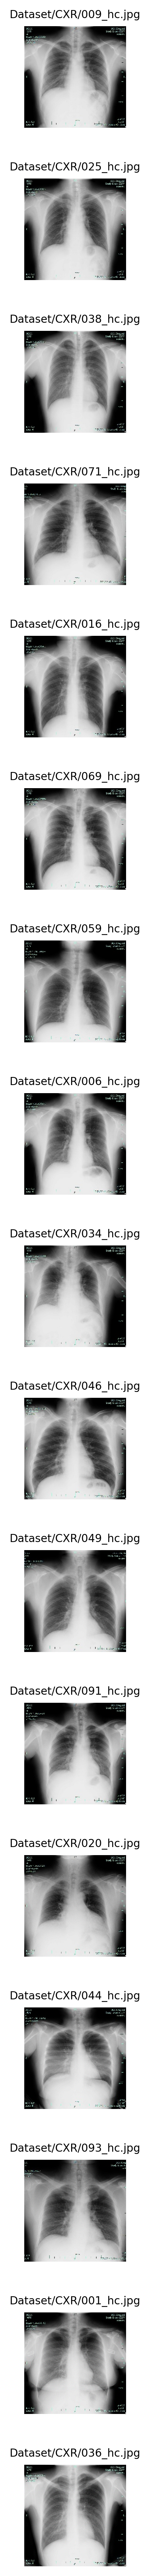

In [ ]:
if len(fp_idx) != 0:
    fig = plt.figure(figsize=(4,len(fp_idx)*2), dpi=300)
    gs = gridspec.GridSpec(
        len(fp_idx), 1,
        # width_ratios=[1],   # ROC wider than confusion matrix
        # wspace=0.3,               # space between subplots
        hspace = 0.5
    )
    demo_img = SegDataset(list(np.array(test_files)[fp_idx]), transform=demo_transform)
    for i in range(len(demo_img)):
        # print(len(demo_img[i]))
        img, mask, sample = demo_img[i]
        ax_img = fig.add_subplot(gs[i, 0])
        ax_img.imshow(img)
        ax_img.set_title(f"{sample['image']}",fontsize=8)
        ax_img.axis("off")
    plt.tight_layout()  
    plt.savefig("output-classification/5-false_prediction_demo/false_positives.pdf", format="pdf",bbox_inches="tight")
    plt.show()
else:
    print("No False Positive samples in test set!")


In [ ]:
if len(fn_idx) != 0:
    fig = plt.figure(figsize=(4,len(fn_idx)*2), dpi=300)
    gs = gridspec.GridSpec(
        len(fn_idx), 1,
        # width_ratios=[1],   # ROC wider than confusion matrix
        # wspace=0.3,               # space between subplots
        hspace = 0.5
    )
    demo_img = SegDataset(list(np.array(test_files)[fn_idx]), transform=demo_transform)
    for i in range(len(demo_img)):
        # print(len(demo_img[i]))
        img, mask, sample = demo_img[i]
        ax_img = fig.add_subplot(gs[i, 0])
        ax_img.imshow(img)
        ax_img.set_title(f"{sample['image']}",fontsize=8)
        ax_img.axis("off")
    plt.tight_layout()  
    plt.savefig("output-classification/5-false_prediction_demo/false_negatives.pdf", format="pdf",bbox_inches="tight")
    plt.show()
else:
    print("No False Negative samples in test set!")